
Hasil Evaluasi K-Means

Metrik       Waktu (s)    Silhouette Score
Euclidean    0.0178       0.6680
Manhattan    0.0164       0.6645
Minkowski    0.0357       0.6676


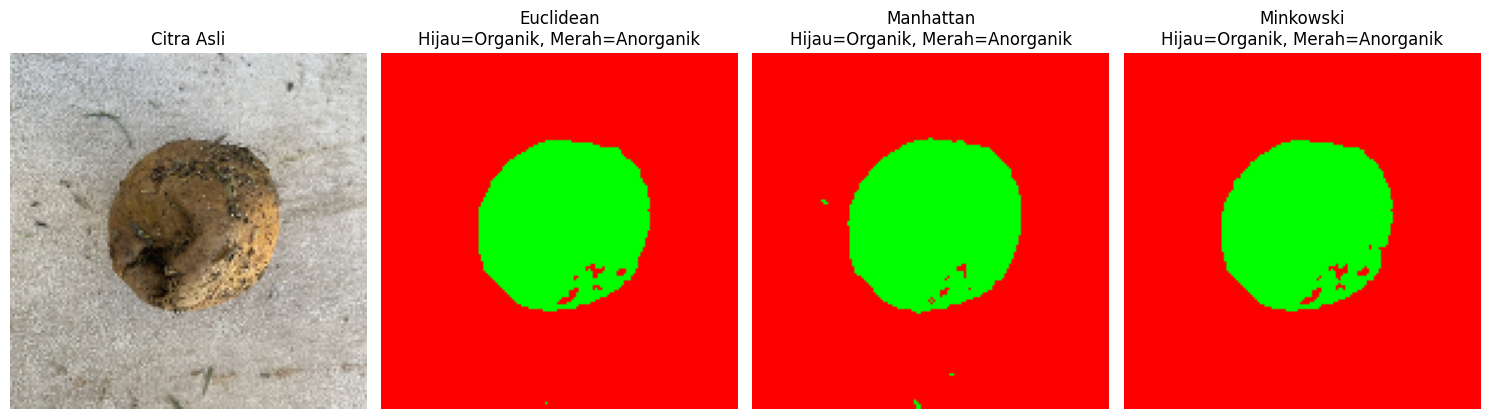

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.metrics import silhouette_score

def hitung_jarak(X, centroids, metric='euclidean', p=3):
    d = X[:, np.newaxis, :] - centroids

    if metric == 'euclidean':
        return np.sqrt((d ** 2).sum(axis=2))

    if metric == 'manhattan':
        return np.abs(d).sum(axis=2)

    if metric == 'minkowski':
        return (np.abs(d) ** p).sum(axis=2) ** (1 / p)

    raise ValueError(f"Metrik tidak dikenal: {metric}")

def kmeans_custom(X, k=2, metric='euclidean', p=3, max_iters=30, tol=1e-4):
    np.random.seed(42)

    centroids = X[np.random.choice(X.shape[0], k, replace=False)]

    for _ in range(max_iters):
        labels = np.argmin(hitung_jarak(X, centroids, metric, p), axis=1)

        centroids_baru = np.array([
            X[labels == i].mean(axis=0)
            if (labels == i).any()
            else centroids[i]
            for i in range(k)
        ])

        if np.all(np.abs(centroids_baru - centroids) < tol):
            break

        centroids = centroids_baru

    return centroids, labels

def interpretasi_sampah(centroids):
    skor = [
        (10 if 0.05 <= h <= 0.48 else 0) +
        (2 if 0.2 <= s <= 0.7 else 0)
        for h, s, _ in centroids
    ]

    if skor[0] != skor[1]:
        idx_organik = int(np.argmax(skor))
    else:
        idx_organik = int(np.argmin(centroids[:, 1]))

    return idx_organik, 1 - idx_organik

def jalankan_eksperimen(path_gambar):
    img_bgr = cv2.imread(path_gambar)

    if img_bgr is None:
        return

    img_resized = cv2.resize(img_bgr, (150, 150))

    img_hsv = cv2.cvtColor(
        cv2.GaussianBlur(img_resized, (5, 5), 0),
        cv2.COLOR_BGR2HSV
    )

    h, w, _ = img_hsv.shape

    piksel = img_hsv.reshape(-1, 3).astype(np.float32)
    piksel /= np.array([179.0, 255.0, 255.0])

    warna = {
        'organik': [0, 255, 0],
        'anorganik': [0, 0, 255]
    }

    hasil_segmentasi = {}

    print("\nHasil Evaluasi K-Means\n")
    print(f"{'Metrik':<12} {'Waktu (s)':<12} {'Silhouette Score'}")

    for metric in ('euclidean', 'manhattan', 'minkowski'):
        mulai = time.perf_counter()

        centroids, labels = kmeans_custom(
            piksel,
            metric=metric
        )

        waktu = time.perf_counter() - mulai

        silhouette = silhouette_score(
            piksel,
            labels,
            sample_size=2000,
            random_state=42
        )

        print(
            f"{metric.capitalize():<12} "
            f"{waktu:<12.4f} "
            f"{silhouette:.4f}"
        )

        idx_org, idx_anorg = interpretasi_sampah(centroids)

        seg = np.zeros((len(labels), 3), dtype=np.uint8)

        seg[labels == idx_org] = warna['organik']
        seg[labels == idx_anorg] = warna['anorganik']

        hasil_segmentasi[metric] = seg.reshape(h, w, 3)

    judul_gambar = [
        (
            "Citra Asli",
            cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
        ),
        *[
            (
                f"{m.capitalize()}\nHijau=Organik, Merah=Anorganik",
                cv2.cvtColor(
                    hasil_segmentasi[m],
                    cv2.COLOR_BGR2RGB
                )
            )
            for m in ('euclidean', 'manhattan', 'minkowski')
        ]
    ]

    fig, axes = plt.subplots(1, 4, figsize=(15, 5))

    for ax, (judul, img) in zip(axes, judul_gambar):
        ax.imshow(img)
        ax.set_title(judul)
        ax.axis('off')

    plt.tight_layout()
    plt.savefig('hasil_segmentasi.png')
    plt.show()

jalankan_eksperimen('Food Organics_2.jpg')